In [1]:
import numpy as np
import matplotlib.pyplot as plt

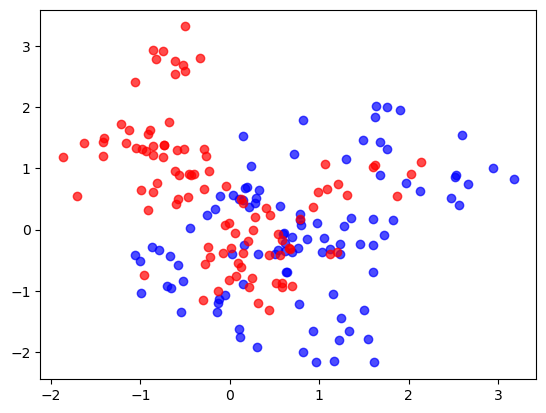

In [2]:
#1
#A

np.random.seed(42)

# Generate m0, m1, ..., m9
means_pos=np.random.multivariate_normal(mean=[1,0],cov=[[1,0],[0,1]],size=10)          #Geometric Meaning- The centers are scattered around (1,0) in a circular cloud. Because equal variance in both directions.

# Generate m'0, m'1, ..., m'9
means_neg=np.random.multivariate_normal(mean=[0,1],cov=[[1,0],[0,1]],size=10)          #Class +1 tends near (1,0) & Class −1 tends near (0,1)

#B&C

xpos=[]
xneg=[]

for i in range(10):
    pts=np.random.multivariate_normal(mean=means_pos[i],cov=[[0.1,0],[0,0.1]],size=10)
    xpos.append(pts)

for j in range(10):
    pts=np.random.multivariate_normal(mean=means_neg[j],cov=[[0.1,0],[0,0.1]],size=10)
    xneg.append(pts)


xpos=np.vstack(xpos)
xneg=np.vstack(xneg)


x = np.vstack((xpos, xneg))
y = np.array([1]*100 + [-1]*100)

plt.scatter(x[y==1,0],x[y==1,1],color='blue',label='+1',alpha=0.7)
plt.scatter(x[y==-1,0],x[y==-1,1],color='red',label='-1',alpha=0.7)

weights: [-0.0752536   0.40973462 -0.23742849]
Training Error = 0.335


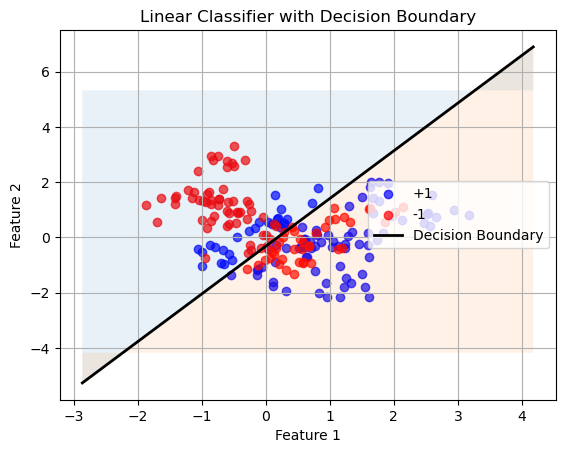

In [3]:
#2

xaug=np.hstack((np.ones((x.shape[0],1)),x))        # xaug=[1 x1 x2]
w=np.linalg.inv(xaug.T@xaug)@(xaug.T@y)            # weight
print("weights:",w)                                # w0 w1 w2

scores=xaug@w                                      # si = w0 + w1.xi1 + w2.xi2

#convert scores to label
y_pred=np.where(scores>0,1,-1)                     # where score is >0 replace, append 1, else -1
training_error=np.mean(y_pred!=y)                  # y_pred = [1, -1, 1, 1, -1]
                                                   # y = [1, -1, -1, 1, -1]
                                                   # y_pred!=y  = [False, false, True, False, False]
                                                   #            = [0 0 1 0 0]  mean=1/5

print("Training Error =", training_error)

x1_vals = np.linspace(x[:,0].min()-1, x[:,0].max()+1, 200)        # Creates 200 equally spaced numbers from a to b.
x2_vals = -(w[0] + w[1]*x1_vals) / w[2]                           # w0 + w1.xi1 + w2.xi2 = 0 ==> xi2=-(w0+w1.x1)/w2

plt.scatter(x[y==1,0],x[y==1,1],color='blue',label='+1',alpha=0.7)
plt.scatter(x[y==-1,0],x[y==-1,1],color='red',label='-1',alpha=0.7)

plt.plot(x1_vals, x2_vals, color='black', linewidth=2, label='Decision Boundary')

plt.fill_between(x1_vals, x2_vals, x[:,1].max()+2, alpha=0.1)

plt.fill_between(x1_vals, x2_vals, x[:,1].min()-2, alpha=0.1)


plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Linear Classifier with Decision Boundary")
plt.legend()
plt.grid(True)
plt.show()

Training Error = 0.165


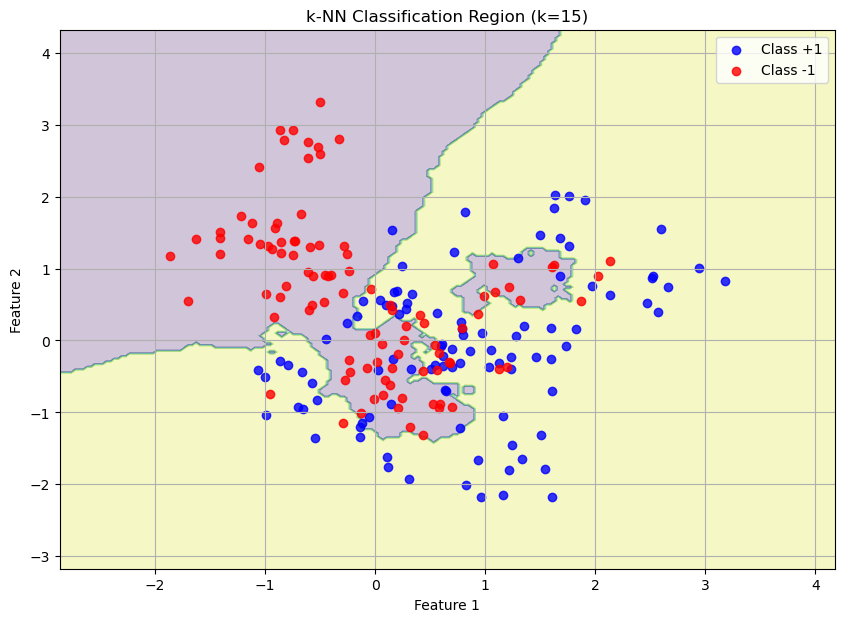

In [4]:
def knn_predict(train_x,train_y,test_points,k):
    predictions = []

    for point in test_points:
        distances=np.sqrt(np.sum((train_x-point)**2,axis=1))

        index=np.argsort(distances)[:k]          # gives index for each distance that could be arranged in increasing order
                                                 # distances = [2.4, 0.7, 1.8, 0.2, 3.1]
                                                 # index = [3, 1, 2, 0, 4]
                                                 # till kth element
        
        nearest_labels=train_y[index]            # train_y = [1, -1, 1, -1, 1]
                                                 # index = [3,1,2]
                                                 # nearest_labels = [-1, -1, 1]

        pred = 1 if np.sum(nearest_labels) > 0 else -1

        predictions.append(pred)

    return np.array(predictions)

k=15

y_pred = knn_predict(x, y, x, k)

training_error = np.mean(y_pred != y)
print("Training Error =", training_error)

x_min, x_max = x[:,0].min() - 1, x[:,0].max() + 1
y_min, y_max = x[:,1].min() - 1, x[:,1].max() + 1

xx, yy = np.meshgrid(                                            # chatGPT
    np.linspace(x_min, x_max, 200), 
    np.linspace(y_min, y_max, 200)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]

Z = knn_predict(x, y, grid_points, k)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,7))

plt.contourf(xx, yy, Z, alpha=0.25)

plt.scatter(x[y==1,0], x[y==1,1],
            color='blue', label='Class +1', alpha=0.8)

plt.scatter(x[y==-1,0], x[y==-1,1],
            color='red', label='Class -1', alpha=0.8)

plt.title("k-NN Classification Region (k=15)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

Training Error = 0.0


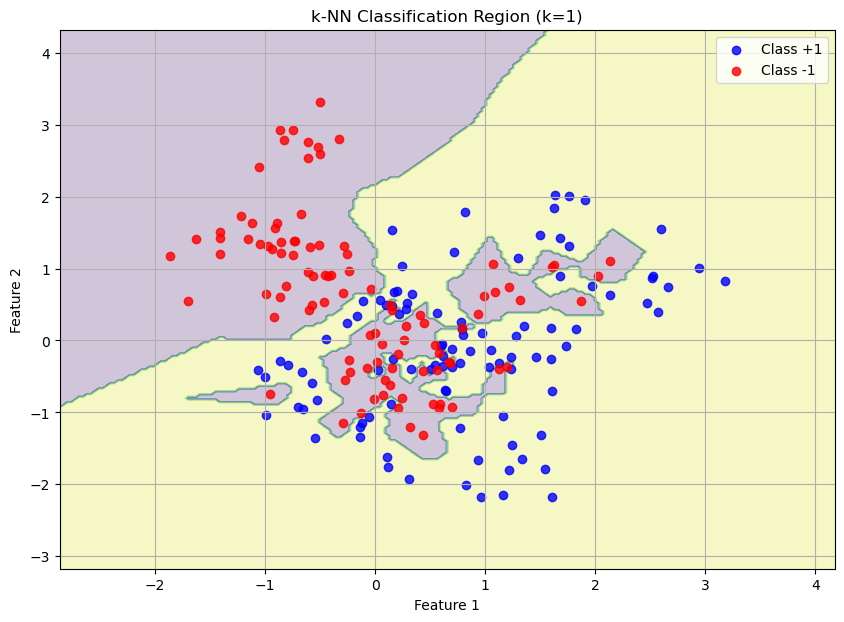

In [5]:
def knn_predict1(train_x,train_y,test_points,k):
    predictions = []

    for point in test_points:
        distances=np.sqrt(np.sum((train_x-point)**2,axis=1))

        index=np.argsort(distances)[:k]

        nearest_labels=train_y[index]

        pred = 1 if np.sum(nearest_labels) > 0 else -1

        predictions.append(pred)

    return np.array(predictions)

k=1

y_pred = knn_predict1(x, y, x, k)

training_error = np.mean(y_pred != y)
print("Training Error =", training_error)

x_min, x_max = x[:,0].min() - 1, x[:,0].max() + 1
y_min, y_max = x[:,1].min() - 1, x[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]

Z = knn_predict(x, y, grid_points, k)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,7))

plt.contourf(xx, yy, Z, alpha=0.25)

plt.scatter(x[y==1,0], x[y==1,1],
            color='blue', label='Class +1', alpha=0.8)

plt.scatter(x[y==-1,0], x[y==-1,1],
            color='red', label='Class -1', alpha=0.8)

plt.title("k-NN Classification Region (k=1)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()